<a href="https://colab.research.google.com/github/Iamjohnko/Data-science-Project-Portfolio/blob/main/Graph_Neural_Networks_for_Large_Scale_Fraud%2C_Waste%2C_and_Abuse_Detection_in_Health_Insurance_Claims.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, classification_report

from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPRegressor

from scipy import stats

In [2]:
df = pd.read_csv("fwa_claims_graph_dataset.csv")
df.head()

,claim_id,patient_id,provider_id,claim_date,patient_age,patient_gender,region,procedure_code,diagnosis_code,units,allowed_amount,billed_amount,fraud_label,billed_to_allowed_ratio,repeat_claim_30d,claim_duration_days
0,CLM000000001,PAT0015796,PROV000037,2025-03-04,64,Male,South,45378,R07,2,3282.031341,3035.078356,0,0.92,0,3
1,CLM000000002,PAT0000861,PROV010216,2019-04-02,80,Male,South,45378,M54,4,7451.684966,7099.410854,0,0.95,0,6
2,CLM000000003,PAT0038159,PROV000196,2018-04-13,74,Female,South,99213,J45,4,416.696879,500.162546,0,1.20,0,2
3,CLM000000004,PAT0044733,PROV007034,2021-01-31,29,Male,West,93000,E11,2,360.310157,403.445738,0,1.12,1,2
4,CLM000000005,PAT0011285,PROV001318,2020-09-30,11,Male,South,80050,M54,2,647.777646,533.803573,0,0.82,0,3


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150000 entries, 0 to 149999
Data columns (total 16 columns):
 #   Column                   Non-Null Count   Dtype  
---  ------                   --------------   -----  
 0   claim_id                 150000 non-null  object 
 1   patient_id               150000 non-null  object 
 2   provider_id              150000 non-null  object 
 3   claim_date               150000 non-null  object 
 4   patient_age              150000 non-null  int64  
 5   patient_gender           150000 non-null  object 
 6   region                   150000 non-null  object 
 7   procedure_code           150000 non-null  int64  
 8   diagnosis_code           150000 non-null  object 
 9   units                    150000 non-null  int64  
 10  allowed_amount           150000 non-null  float64
 11  billed_amount            150000 non-null  float64
 12  fraud_label              150000 non-null  int64  
 13  billed_to_allowed_ratio  150000 non-null  float64
 14  repe

In [4]:
fraud_rate = df["fraud_label"].mean()
print(f"Fraud prevalence: {fraud_rate:.2%}")

Fraud prevalence: 3.52%


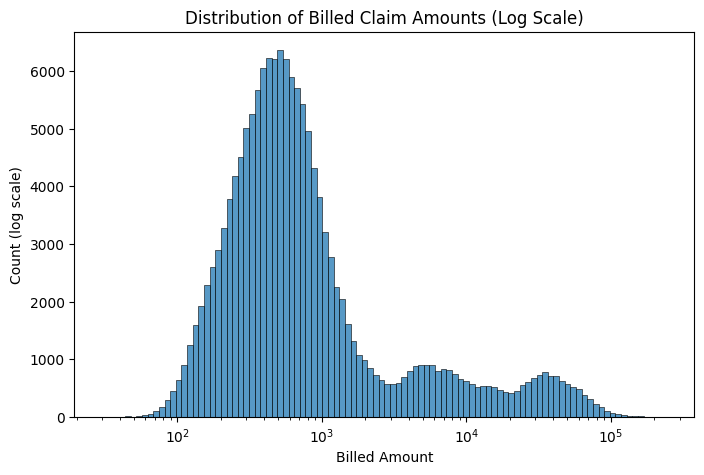

In [5]:
plt.figure(figsize=(8,5))
sns.histplot(df["billed_amount"], bins=100, log_scale=True)
plt.title("Distribution of Billed Claim Amounts (Log Scale)")
plt.xlabel("Billed Amount")
plt.ylabel("Count (log scale)")
plt.show()

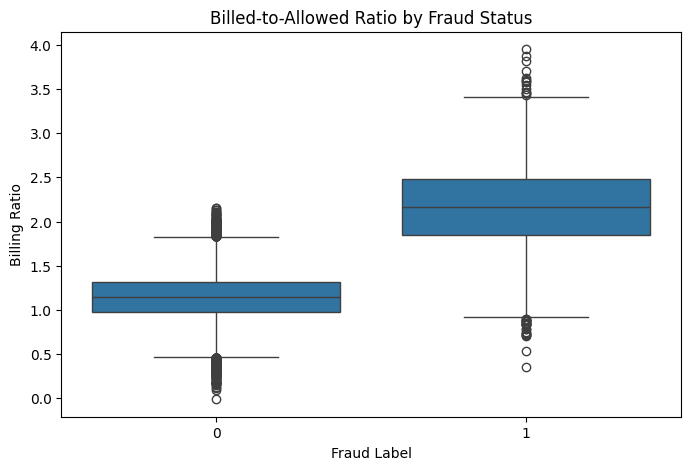

In [6]:
plt.figure(figsize=(8,5))
sns.boxplot(x="fraud_label", y="billed_to_allowed_ratio", data=df)
plt.title("Billed-to-Allowed Ratio by Fraud Status")
plt.xlabel("Fraud Label")
plt.ylabel("Billing Ratio")
plt.show()

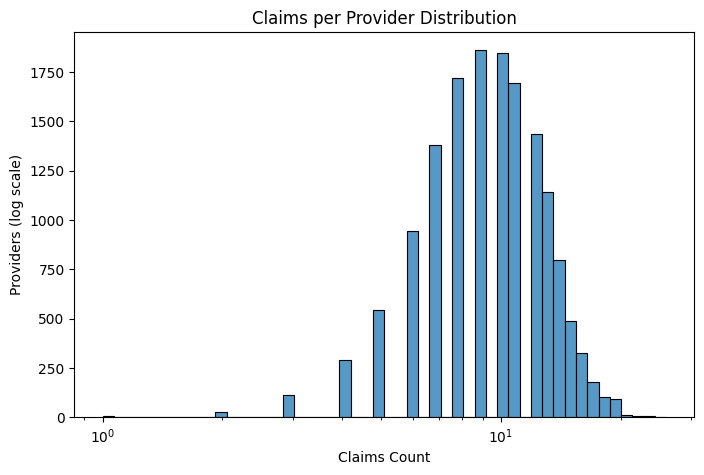

In [7]:
provider_claims = df.groupby("provider_id").size()

plt.figure(figsize=(8,5))
sns.histplot(provider_claims, bins=50, log_scale=True)
plt.title("Claims per Provider Distribution")
plt.xlabel("Claims Count")
plt.ylabel("Providers (log scale)")
plt.show()

In [8]:
fraudulent_claims = df[df['fraud_label'] == 1.0]

unique_fraud_patients = fraudulent_claims['patient_id'].unique()
unique_fraud_providers = fraudulent_claims['provider_id'].unique()

print(f"Number of unique patients involved in fraudulent claims: {len(unique_fraud_patients)}")
print(f"Number of unique providers involved in fraudulent claims: {len(unique_fraud_providers)}")

print("\nFirst 10 unique patient IDs involved in fraudulent claims:")
for patient_id in unique_fraud_patients[:10]:
    print(patient_id)

print("\nFirst 10 unique provider IDs involved in fraudulent claims:")
for provider_id in unique_fraud_providers[:10]:
    print(provider_id)

Number of unique patients involved in fraudulent claims: 5008
Number of unique providers involved in fraudulent claims: 4482

First 10 unique patient IDs involved in fraudulent claims:
PAT0021963
PAT0043324
PAT0001586
PAT0021244
PAT0002696
PAT0023420
PAT0021835
PAT0015708
PAT0021977
PAT0002912

First 10 unique provider IDs involved in fraudulent claims:
PROV001373
PROV013755
PROV001687
PROV013525
PROV012546
PROV006033
PROV000912
PROV011554
PROV004719
PROV000890


In [9]:
fraud = df[df["fraud_label"]==1]["billed_to_allowed_ratio"]
non_fraud = df[df["fraud_label"]==0]["billed_to_allowed_ratio"]

t_stat, p_val = stats.ttest_ind(fraud, non_fraud, equal_var=False)

print(f"T-statistic: {t_stat:.3f}")
print(f"P-value: {p_val:.6f}")

T-statistic: 155.129
P-value: 0.000000


In [10]:
features = [
    "patient_age",
    "units",
    "allowed_amount",
    "billed_amount",
    "billed_to_allowed_ratio",
    "repeat_claim_30d",
    "claim_duration_days"
]

X = df[features]
y = df["fraud_label"]

In [11]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [12]:
iso = IsolationForest(
    n_estimators=200,
    contamination=0.035,
    random_state=42
)

iso.fit(X_scaled)
df["iso_score"] = -iso.decision_function(X_scaled)

# Drop rows where 'fraud_label' is NaN before calculating AUC score
df_cleaned = df.dropna(subset=['fraud_label'])
y_cleaned = df_cleaned['fraud_label']
iso_score_cleaned = df_cleaned['iso_score']

auc_iso = roc_auc_score(y_cleaned, iso_score_cleaned)
print(f"Isolation Forest ROC-AUC: {auc_iso:.4f}")

Isolation Forest ROC-AUC: 0.8657


In [13]:
y_cleaned_for_split = y.dropna()
X_scaled_cleaned_for_split = X_scaled[y.notna()]

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled_cleaned_for_split, y_cleaned_for_split, test_size=0.25, stratify=y_cleaned_for_split, random_state=42
)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)

y_pred_prob = lr.predict_proba(X_test)[:,1]

auc_lr = roc_auc_score(y_test, y_pred_prob)
print(f"Logistic Regression ROC-AUC: {auc_lr:.4f}")

Logistic Regression ROC-AUC: 0.9745


In [14]:
ae = MLPRegressor(
    hidden_layer_sizes=(32,16,32),
    activation="relu",
    max_iter=50,
    random_state=42
)

# Filter out rows with NaNs from X_scaled and y
X_scaled_cleaned = X_scaled[y.notna()]
y_cleaned_for_ae = y.dropna()

ae.fit(X_scaled_cleaned, X_scaled_cleaned)

X_recon = ae.predict(X_scaled_cleaned)
recon_error = np.mean((X_scaled_cleaned - X_recon)**2, axis=1)

# Create a Series with the original df index to align reconstruction_error
recon_error_series = pd.Series(recon_error, index=y_cleaned_for_ae.index)
df["reconstruction_error"] = recon_error_series

auc_ae = roc_auc_score(y_cleaned_for_ae, recon_error)
print(f"Autoencoder ROC-AUC: {auc_ae:.4f}")

Autoencoder ROC-AUC: 0.8208


In [15]:
results = pd.DataFrame({
    "Model": ["Isolation Forest", "Logistic Regression", "Autoencoder"],
    "ROC-AUC": [auc_iso, auc_lr, auc_ae]
})

results

,Model,ROC-AUC
0,Isolation Forest,0.865745
1,Logistic Regression,0.974515
2,Autoencoder,0.820762


In [16]:
df["fraud_risk_score"] = (
    0.4 * df["iso_score"].rank(pct=True) +
    0.6 * df["reconstruction_error"].rank(pct=True)
)

df[[
    "claim_id",
    "provider_id",
    "billed_amount",
    "fraud_risk_score",
    "fraud_label"
]].head()

,claim_id,provider_id,billed_amount,fraud_risk_score,fraud_label
0,CLM000000001,PROV000037,3035.078356,0.652327,0
1,CLM000000002,PROV010216,7099.410854,0.821672,0
2,CLM000000003,PROV000196,500.162546,0.443233,0
3,CLM000000004,PROV007034,403.445738,0.452468,0
4,CLM000000005,PROV001318,533.803573,0.428277,0


In [17]:
!pip install torch torch-geometric


In [18]:
import pandas as pd
import torch
from torch_geometric.data import Data

In [19]:
# Clean the DataFrame by dropping the row with NaN in 'fraud_label' for consistent GNN data
df_gnn_data = df.dropna(subset=['fraud_label']).copy()

claim_ids = df_gnn_data["claim_id"].astype("category").cat.codes
patient_ids = df_gnn_data["patient_id"].astype("category").cat.codes
provider_ids = df_gnn_data["provider_id"].astype("category").cat.codes

num_claims = claim_ids.nunique()
num_patients = patient_ids.nunique()
num_providers = provider_ids.nunique()

In [20]:
claim_features = torch.tensor(
    df_gnn_data[[
        "units",
        "allowed_amount",
        "billed_amount",
        "billed_to_allowed_ratio",
        "repeat_claim_30d",
        "claim_duration_days"
    ]].values,
    dtype=torch.float
)

labels = torch.tensor(df_gnn_data["fraud_label"].values, dtype=torch.long)


In [21]:
# Patient → Claim edges
edge_patient_claim = torch.tensor([
    patient_ids.values,
    claim_ids.values
], dtype=torch.long)

# Provider → Claim edges
edge_provider_claim = torch.tensor([
    provider_ids.values.astype(np.int64) + num_patients,
    claim_ids.values
], dtype=torch.long)

edge_index = torch.cat([edge_patient_claim, edge_provider_claim], dim=1)

/tmp/ipython-input-3500613831.py:2: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  edge_patient_claim = torch.tensor([


In [22]:
data = Data(
    x=claim_features,
    edge_index=edge_index,
    y=labels
)

In [23]:
import torch.nn as nn
from torch_geometric.nn import SAGEConv

In [24]:
class FraudGNN(nn.Module):
    def __init__(self, in_channels):
        super().__init__()
        self.conv1 = SAGEConv(in_channels, 32)
        self.conv2 = SAGEConv(32, 16)
        self.classifier = nn.Linear(16, 2)

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index).relu()
        return self.classifier(x)

In [25]:
model = FraudGNN(in_channels=claim_features.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
criterion = nn.CrossEntropyLoss()

In [26]:
for epoch in range(30):
    model.train()
    optimizer.zero_grad()

    out = model(data.x, data.edge_index)
    loss = criterion(out, data.y)

    loss.backward()
    optimizer.step()

    print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

Epoch 1, Loss: 32.2604
Epoch 2, Loss: 464.0861
Epoch 3, Loss: 43.5432
Epoch 4, Loss: 37.6533
Epoch 5, Loss: 52.7791
Epoch 6, Loss: 61.7664
Epoch 7, Loss: 66.0676
Epoch 8, Loss: 66.8271
Epoch 9, Loss: 65.0604
Epoch 10, Loss: 61.5612
Epoch 11, Loss: 57.0337
Epoch 12, Loss: 52.1597
Epoch 13, Loss: 47.9653
Epoch 14, Loss: 44.2460
Epoch 15, Loss: 41.5206
Epoch 16, Loss: 38.8577
Epoch 17, Loss: 34.7908
Epoch 18, Loss: 30.6157
Epoch 19, Loss: 26.8324
Epoch 20, Loss: 23.3625
Epoch 21, Loss: 20.0316
Epoch 22, Loss: 16.6996
Epoch 23, Loss: 13.4233
Epoch 24, Loss: 10.1499
Epoch 25, Loss: 6.9445
Epoch 26, Loss: 4.0850
Epoch 27, Loss: 2.8482
Epoch 28, Loss: 3.8722
Epoch 29, Loss: 2.5161
Epoch 30, Loss: 0.9118


In [27]:
model.eval()
with torch.no_grad():
    logits = model(data.x, data.edge_index)
    fraud_prob = torch.softmax(logits, dim=1)[:,1]

# Create a Series with the original df_gnn_data index to align gnn_fraud_score
gnn_fraud_score_series = pd.Series(fraud_prob.numpy(), index=df_gnn_data.index)
df["gnn_fraud_score"] = gnn_fraud_score_series

In [28]:
display(df[['claim_id', 'fraud_label', 'gnn_fraud_score']].head())

,claim_id,fraud_label,gnn_fraud_score
0,CLM000000001,0,0.476551
1,CLM000000002,0,0.476551
2,CLM000000003,0,0.000000
3,CLM000000004,0,0.118602
4,CLM000000005,0,0.476551


In [29]:
import pandas as pd

# Top 1% threshold
top_1pct_threshold = df['gnn_fraud_score'].quantile(0.99)

top_gnn_cases = (
    df[df['gnn_fraud_score'] >= top_1pct_threshold]
    .sort_values('gnn_fraud_score', ascending=False)
)

print("Top 1% GNN Fraud Risk Claims")
display(top_gnn_cases.head(20))

Top 1% GNN Fraud Risk Claims


,claim_id,patient_id,provider_id,claim_date,patient_age,patient_gender,region,procedure_code,diagnosis_code,units,allowed_amount,billed_amount,fraud_label,billed_to_allowed_ratio,repeat_claim_30d,claim_duration_days,iso_score,reconstruction_error,fraud_risk_score,gnn_fraud_score
648,CLM000000649,PAT0037099,PROV012572,2018-09-13,23,Female,South,27447,R07,2,27951.913342,71162.743152,1,2.55,0,5,0.070909,0.000502,0.996113,1.0
37713,CLM000037714,PAT0004474,PROV004942,2020-07-29,89,Male,West,27447,C50,1,11349.013077,23653.691544,1,2.08,1,3,0.064800,0.000008,0.906577,1.0
37961,CLM000037962,PAT0011614,PROV011336,2024-04-27,72,Male,West,27447,R07,3,34454.271960,102642.008694,1,2.98,0,2,0.101499,0.000078,0.991059,1.0
37985,CLM000037986,PAT0039648,PROV007623,2021-08-24,67,Female,South,27447,I10,2,23564.620844,54412.628776,1,2.31,1,6,0.082077,0.000309,0.996516,1.0
38460,CLM000038461,PAT0037161,PROV004822,2022-02-06,60,Male,West,45378,I10,3,4917.568508,6961.453119,0,1.42,0,2,-0.157211,0.000014,0.783964,1.0
43822,CLM000043823,PAT0036901,PROV002693,2025-05-08,44,Male,South,27447,R07,6,83536.027945,242651.994301,1,2.90,0,3,0.149190,0.001562,0.999869,1.0
45420,CLM000045421,PAT0002462,PROV007865,2023-06-11,24,Female,Northeast,27447,M54,2,21910.427560,47928.361252,1,2.19,0,1,0.038432,0.000566,0.992523,1.0
45518,CLM000045519,PAT0015090,PROV000412,2018-03-01,88,Female,Northeast,27447,J45,3,29679.475903,66876.100863,1,2.25,1,3,0.094484,0.000740,0.997952,1.0
140734,CLM000140735,PAT0046730,PROV012760,2024-08-30,0,Female,South,27447,E11,2,29003.027880,84241.602369,1,2.90,1,3,0.126210,0.000145,0.996980,1.0
48576,CLM000048577,PAT0023598,PROV004631,2024-07-20,47,Male,Northeast,93000,M54,5,894.942917,949.124631,0,1.06,1,4,-0.114339,0.000003,0.708685,1.0


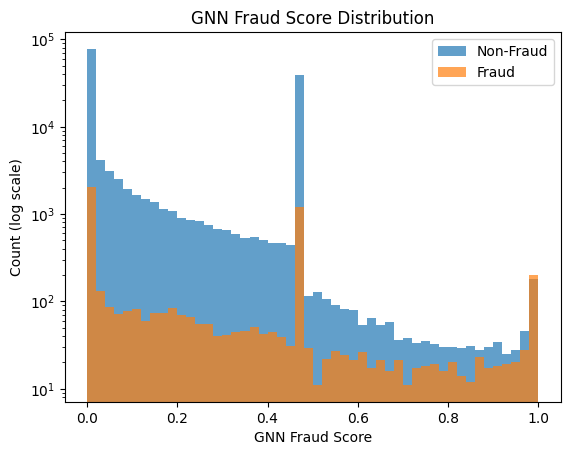

In [30]:
import matplotlib.pyplot as plt

fraud_scores = df[df['fraud_label'] == 1]['gnn_fraud_score']
nonfraud_scores = df[df['fraud_label'] == 0]['gnn_fraud_score']

plt.figure()
plt.hist(nonfraud_scores, bins=50, alpha=0.7, label='Non-Fraud')
plt.hist(fraud_scores, bins=50, alpha=0.7, label='Fraud')
plt.yscale('log')
plt.xlabel('GNN Fraud Score')
plt.ylabel('Count (log scale)')
plt.legend()
plt.title('GNN Fraud Score Distribution')
plt.show()

In [31]:
# Add Logistic Regression scores to the DataFrame
# Aligning y_test with df's index is necessary if y_test is a subset or re-indexed
# For simplicity, if y_pred_prob corresponds to the original df for which y_test was derived,
# we need to ensure correct alignment.

# Let's assume y_pred_prob was calculated for the cleaned dataset used for LR (y_cleaned_for_split)
# We will create a Series and assign it to df, aligning by index.
logreg_score_series = pd.Series(y_pred_prob, index=y_test.index) # y_test has the correct index from df
df["logreg_score"] = logreg_score_series

model_scores = df[['gnn_fraud_score', 'logreg_score', 'iso_score']]

correlation_matrix = model_scores.corr()
print("Model Score Correlation Matrix")
display(correlation_matrix)

Model Score Correlation Matrix


,gnn_fraud_score,logreg_score,iso_score
gnn_fraud_score,1.000000,0.103746,-0.166888
logreg_score,0.103746,1.000000,0.322114
iso_score,-0.166888,0.322114,1.000000


In [32]:
def top_decile_ids(df, score_col):
    threshold = df[score_col].quantile(0.90)
    return set(df[df[score_col] >= threshold].index)

gnn_top = top_decile_ids(df, 'gnn_fraud_score')
logreg_top = top_decile_ids(df, 'logreg_score')
iforest_top = top_decile_ids(df, 'iso_score')

print("Top-decile overlap:")
print("GNN & LogReg:", len(gnn_top & logreg_top))
print("GNN & IsolationForest:", len(gnn_top & iforest_top))

Top-decile overlap:
GNN & LogReg: 1159
GNN & IsolationForest: 1540


In [33]:
from sklearn.model_selection import train_test_split

X = df[['gnn_fraud_score']]
y = df['fraud_label']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.3, stratify=y, random_state=42
)

In [34]:
from sklearn.linear_model import LogisticRegression

platt = LogisticRegression()
platt.fit(X_train, y_train)

df['gnn_platt_score'] = platt.predict_proba(X)[:, 1]

In [35]:
from sklearn.isotonic import IsotonicRegression

iso = IsotonicRegression(out_of_bounds='clip')
iso.fit(X_train['gnn_fraud_score'], y_train)

df['gnn_isotonic_score'] = iso.transform(df['gnn_fraud_score'])

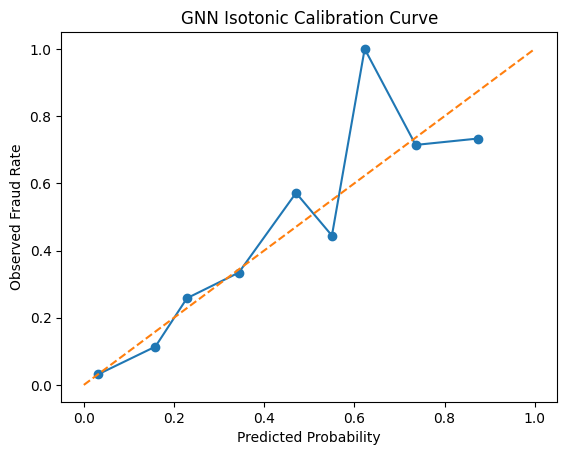

In [36]:
from sklearn.calibration import calibration_curve

prob_true, prob_pred = calibration_curve(
    y_val, df.loc[y_val.index, 'gnn_isotonic_score'], n_bins=10
)

plt.figure()
plt.plot(prob_pred, prob_true, marker='o')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('Predicted Probability')
plt.ylabel('Observed Fraud Rate')
plt.title('GNN Isotonic Calibration Curve')
plt.show()

In [37]:
ENSEMBLE_WEIGHTS = {
    'gnn_isotonic_score': 0.40,   # strongest relational signal
    'logreg_score': 0.30,         # interpretable baseline
    'iforest_score': 0.20,        # fast anomaly detection
    'autoencoder_score': 0.10     # novelty detection
}

In [38]:
df['ensemble_fraud_score'] = (
    ENSEMBLE_WEIGHTS['gnn_isotonic_score'] * df['gnn_isotonic_score'] +
    ENSEMBLE_WEIGHTS['logreg_score'] * df['logreg_score'] +
    ENSEMBLE_WEIGHTS['iforest_score'] * df['iso_score'] +
    ENSEMBLE_WEIGHTS['autoencoder_score'] * df['reconstruction_error']
)

In [39]:
SIU_THRESHOLDS = {
    'auto_approve': df['ensemble_fraud_score'].quantile(0.80),
    'light_review': df['ensemble_fraud_score'].quantile(0.90),
    'manual_review': df['ensemble_fraud_score'].quantile(0.97),
    'siu_escalation': df['ensemble_fraud_score'].quantile(0.99)
}

In [40]:
def assign_siu_action(score, thresholds):
    if score < thresholds['auto_approve']:
        return 'AUTO_APPROVE'
    elif score < thresholds['light_review']:
        return 'LIGHT_REVIEW'
    elif score < thresholds['manual_review']:
        return 'MANUAL_REVIEW'
    else:
        return 'SIU_ESCALATION'

df['siu_action'] = df['ensemble_fraud_score'].apply(
    lambda x: assign_siu_action(x, SIU_THRESHOLDS)
)

In [41]:
siu_summary = (
    df.groupby('siu_action')
      .agg(
          total_claims=('fraud_label', 'count'),
          fraud_cases=('fraud_label', 'sum'),
          fraud_rate=('fraud_label', 'mean')
      )
      .sort_values('fraud_rate', ascending=False)
)

print("SIU Threshold Performance Summary")
display(siu_summary)

SIU Threshold Performance Summary


,total_claims,fraud_cases,fraud_rate
siu_action,,,
MANUAL_REVIEW,2625,169,0.064381
SIU_ESCALATION,113625,4981,0.043837
LIGHT_REVIEW,3750,40,0.010667
AUTO_APPROVE,30000,95,0.003167


In [42]:
from sklearn.metrics import roc_auc_score

# Drop rows with NaN values in either 'fraud_label' or 'ensemble_fraud_score'
# before calculating the AUC.
cleaned_df_for_auc = df.dropna(subset=['fraud_label', 'ensemble_fraud_score'])

ensemble_auc = roc_auc_score(
    cleaned_df_for_auc['fraud_label'],
    cleaned_df_for_auc['ensemble_fraud_score']
)

print(f"Ensemble ROC–AUC: {ensemble_auc:.4f}")

Ensemble ROC–AUC: 0.9615


In [43]:
import numpy as np

COST_FALSE_POSITIVE = 250      # Cost of unnecessary investigation
COST_FALSE_NEGATIVE = 0.75     # % of claim amount lost to fraud

def expected_cost(threshold, df):
    preds = (df['ensemble_fraud_score'] >= threshold).astype(int)

    fp = ((preds == 1) & (df['fraud_label'] == 0)).sum()
    fn_loss = (
        df.loc[(preds == 0) & (df['fraud_label'] == 1), 'billed_amount']
        * COST_FALSE_NEGATIVE
    ).sum()

    return fp * COST_FALSE_POSITIVE + fn_loss

In [44]:
threshold_grid = np.linspace(0.01, 0.99, 200)

costs = [
    expected_cost(t, df) for t in threshold_grid
]

optimal_threshold = threshold_grid[np.argmin(costs)]

print(f"Optimal Cost-Based Threshold: {optimal_threshold:.4f}")

Optimal Cost-Based Threshold: 0.0494


In [45]:
provider_thresholds = {}

for provider_id_val in df['provider_id'].unique(): # Changed 'provider_type' to 'provider_id'
    subset = df[df['provider_id'] == provider_id_val] # Changed to use 'provider_id'

    # Ensure the subset is not empty before calculating costs
    if not subset.empty:
        grid = np.linspace(0.01, 0.99, 100)
        costs = [expected_cost(t, subset) for t in grid]

        if costs: # Ensure costs list is not empty
            provider_thresholds[provider_id_val] = grid[np.argmin(costs)]

print("Provider-Specific Thresholds")
for k, v in provider_thresholds.items():
    print(f"{k}: {v:.3f}")

Provider-Specific Thresholds
PROV000037: 0.010
PROV010216: 0.010
PROV000196: 0.010
PROV007034: 0.030
PROV001318: 0.010
PROV004689: 0.010
PROV013757: 0.010
PROV008637: 0.010
PROV001373: 0.010
PROV006374: 0.010
PROV002831: 0.030
PROV010908: 0.010
PROV011351: 0.010
PROV012821: 0.010
PROV007965: 0.020
PROV010941: 0.030
PROV012560: 0.010
PROV009515: 0.010
PROV011416: 0.010
PROV012025: 0.010
PROV009974: 0.010
PROV003615: 0.010
PROV008533: 0.010
PROV007181: 0.010
PROV009331: 0.010
PROV008454: 0.030
PROV004822: 0.010
PROV004687: 0.010
PROV005163: 0.010
PROV008274: 0.010
PROV004575: 0.020
PROV004531: 0.010
PROV006219: 0.010
PROV006569: 0.010
PROV010329: 0.010
PROV011474: 0.010
PROV001129: 0.010
PROV011308: 0.010
PROV002062: 0.010
PROV002541: 0.010
PROV011704: 0.010
PROV010964: 0.010
PROV006970: 0.010
PROV006571: 0.010
PROV013755: 0.010
PROV000183: 0.010
PROV008485: 0.010
PROV001186: 0.010
PROV012519: 0.020
PROV005038: 0.010
PROV005040: 0.010
PROV013530: 0.050
PROV012200: 0.040
PROV006164: 0.020

In [46]:
import pandas as pd
import numpy as np

# Load data
# df = pd.read_csv("fwa_claims_graph_dataset.csv") # This line was removed as it was overwriting the df with the gnn_fraud_score

score_col = "gnn_fraud_score"

summary_stats = {
    "mean_score": df[score_col].mean(),
    "median_score": df[score_col].median(),
    "std_dev": df[score_col].std(),
    "p90": df[score_col].quantile(0.90),
    "p95": df[score_col].quantile(0.95),
    "p99": df[score_col].quantile(0.99),
    "max_score": df[score_col].max()
}

summary_df = pd.DataFrame(summary_stats, index=["Value"])
print(summary_df)

       mean_score  median_score   std_dev       p90       p95       p99  \
Value    0.167505      0.007292  0.218962  0.476551  0.476551  0.588344   

       max_score  
Value        1.0  


In [47]:
def risk_bucket(score):
    if score < 0.01:
        return "Very Low"
    elif score < 0.05:
        return "Low"
    elif score < 0.15:
        return "Medium"
    else:
        return "High"

df["risk_tier"] = df[score_col].apply(risk_bucket)

tier_summary = df["risk_tier"].value_counts(normalize=True) * 100
print(tier_summary)

risk_tier
Very Low    50.894000
High        36.001333
Medium       6.715333
Low          6.389333
Name: proportion, dtype: float64


In [48]:
df_sorted = df.sort_values(score_col, ascending=False)

top_1pct = int(len(df_sorted) * 0.01)
top_5pct = int(len(df_sorted) * 0.05)

concentration = {
    "Top 1% avg score": df_sorted.head(top_1pct)[score_col].mean(),
    "Top 5% avg score": df_sorted.head(top_5pct)[score_col].mean(),
    "Overall avg score": df_sorted[score_col].mean()
}

print(pd.DataFrame(concentration, index=["Value"]))

       Top 1% avg score  Top 5% avg score  Overall avg score
Value          0.824848          0.551064           0.167505


In [49]:
if "fraud_label" in df.columns:
    fraud_stats = df.groupby("fraud_label")[score_col].describe()
    print(fraud_stats)

                count      mean       std  min           25%       50%  \
fraud_label                                                              
0            144715.0  0.163927  0.215138  0.0  4.972972e-18  0.005998   
1              5285.0  0.265476  0.289120  0.0  2.357714e-08  0.169889   

                  75%  max  
fraud_label                 
0            0.476551  1.0  
1            0.476551  1.0  


In [50]:
df["score_percentile"] = df[score_col].rank(pct=True)

high_risk_entities = df[df["score_percentile"] > 0.99][
    ["claim_id", score_col, "score_percentile"]
]

print(high_risk_entities.head(10))

          claim_id  gnn_fraud_score  score_percentile
101   CLM000000102         0.719741          0.993127
250   CLM000000251         0.797711          0.994440
436   CLM000000437         0.881238          0.995720
444   CLM000000445         0.647146          0.991653
448   CLM000000449         0.930333          0.996500
648   CLM000000649         1.000000          0.999717
925   CLM000000926         0.970876          0.997213
1097  CLM000001098         0.657710          0.991873
1108  CLM000001109         0.847400          0.995207
1223  CLM000001224         0.855007          0.995293
